In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

fund = nav[nav["amfi_code"] == 119599].copy()

fund = fund.sort_values("date")

fund["daily_return"] = fund["nav"].pct_change()

fund = fund.dropna()

In [2]:
mu = fund["daily_return"].mean()

sigma = fund["daily_return"].std()

print(mu, sigma)

0.00020131692580289563 0.015717101489290827


In [3]:
n_simulations = 1000

n_days = 252 * 5

last_nav = fund["nav"].iloc[-1]

simulations = np.zeros((n_days, n_simulations))

for i in range(n_simulations):

    prices = [last_nav]

    for d in range(n_days):

        shock = np.random.normal(mu, sigma)

        prices.append(prices[-1] * (1 + shock))

    simulations[:, i] = prices[1:]

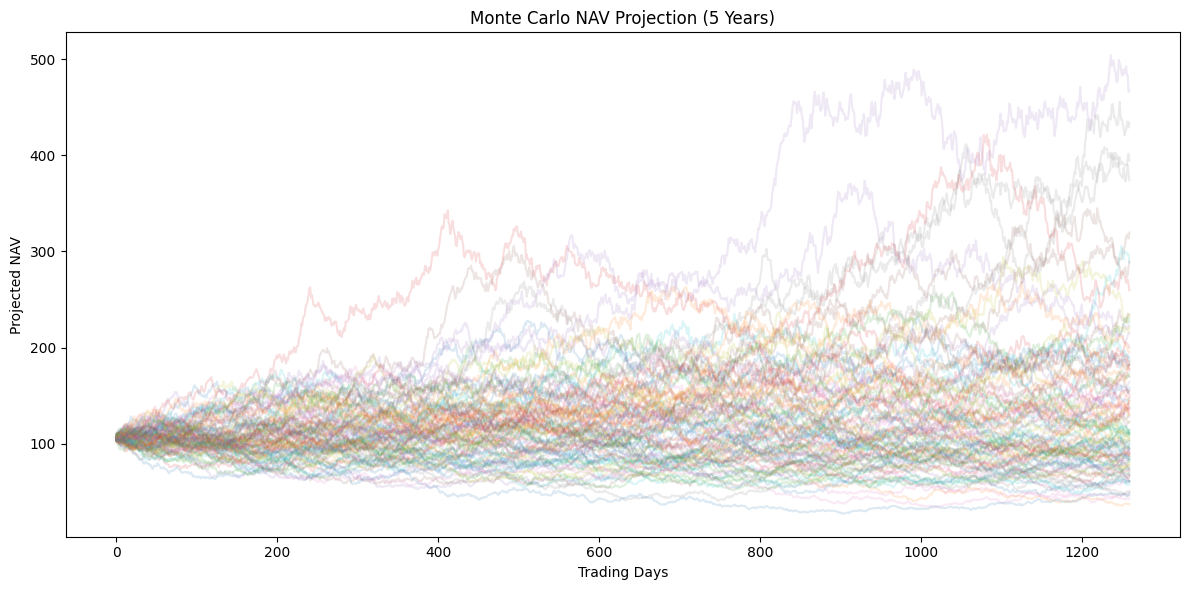

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(simulations[:, :100], alpha=0.15)

plt.title("Monte Carlo NAV Projection (5 Years)")

plt.xlabel("Trading Days")

plt.ylabel("Projected NAV")

plt.tight_layout()

plt.savefig(
    "../reports/monte_carlo_projection.png",
    dpi=300
)

plt.show()

In [5]:
median_path = np.median(simulations, axis=1)

upper = np.percentile(simulations, 95, axis=1)

lower = np.percentile(simulations, 5, axis=1)

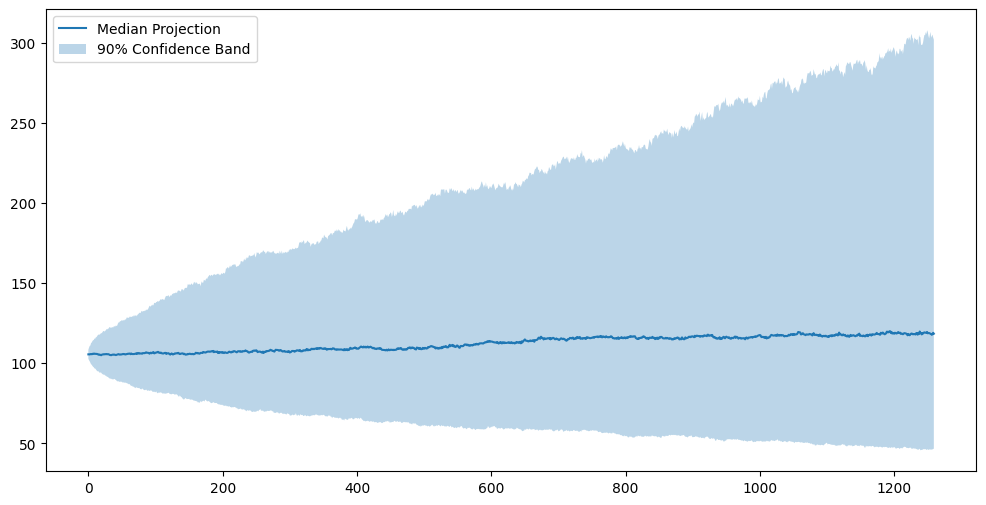

In [6]:
plt.figure(figsize=(12,6))

plt.plot(median_path,label="Median Projection")

plt.fill_between(
    range(len(median_path)),
    lower,
    upper,
    alpha=0.3,
    label="90% Confidence Band"
)

plt.legend()

plt.savefig(
    "../reports/monte_carlo_confidence_band.png",
    dpi=300
)

Monte Carlo simulation was performed using historical daily returns.
1000 future scenarios were generated over a 5-year horizon.

The median trajectory indicated continued NAV growth while
confidence bands captured uncertainty arising from market volatility.